In [1]:
import matplotlib as pl
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sc
import scipy as sp
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

# Aufgabe B2
## Teil 1

In [2]:
# Team A: Einführung der Daten
daten = pd.DataFrame(
    {
        "x": [12, 6, 4, 1, 0, 3, 6],
        "y": [2, 1, 10, 6, 3, 0, 12],
    },
    index=[f"P{i}" for i in range(7)],
)

display(daten)

,x,y
P0,12,2
P1,6,1
P2,4,10
P3,1,6
P4,0,3
P5,3,0
P6,6,12


#### a)

In [3]:
# Paarweise euklidische Distanzmatrix
pairwise_distance = pairwise_distances(daten[["x", "y"]], metric="euclidean")
distanzmatrix = pd.DataFrame(pairwise_distance, index=daten.index, columns=daten.index)

# Kleinste Distanz ohne Hauptdiagonale bestimmen
distanz_ohne_diagonale = pairwise_distance.copy()
np.fill_diagonal(distanz_ohne_diagonale, np.inf)
i, j = np.unravel_index(np.argmin(distanz_ohne_diagonale), distanz_ohne_diagonale.shape)

punkt_1 = daten.index[i]
punkt_2 = daten.index[j]
min_distanz = pairwise_distance[i, j]

display(
    distanzmatrix.style
    .format("{:.2f}")
    .background_gradient(cmap="Blues")
    .set_caption("Paarweise euklidische Distanzmatrix")
)

ergebnis = pd.DataFrame(
    {
        "Punkt 1": [punkt_1],
        "Punkt 2": [punkt_2],
        "Distanz": [round(min_distanz, 4)],
    }
)

display(ergebnis.style.hide(axis="index").set_caption("Nächstes Punktepaar"))

,P0,P1,P2,P3,P4,P5,P6
P0,0.00,6.08,11.31,11.70,12.04,9.22,11.66
P1,6.08,0.00,9.22,7.07,6.32,3.16,11.00
P2,11.31,9.22,0.00,5.00,8.06,10.05,2.83
P3,11.70,7.07,5.00,0.00,3.16,6.32,7.81
P4,12.04,6.32,8.06,3.16,0.00,4.24,10.82
P5,9.22,3.16,10.05,6.32,4.24,0.00,12.37
P6,11.66,11.00,2.83,7.81,10.82,12.37,0.00


Punkt 1,Punkt 2,Distanz
P2,P6,2.828400


#### b)

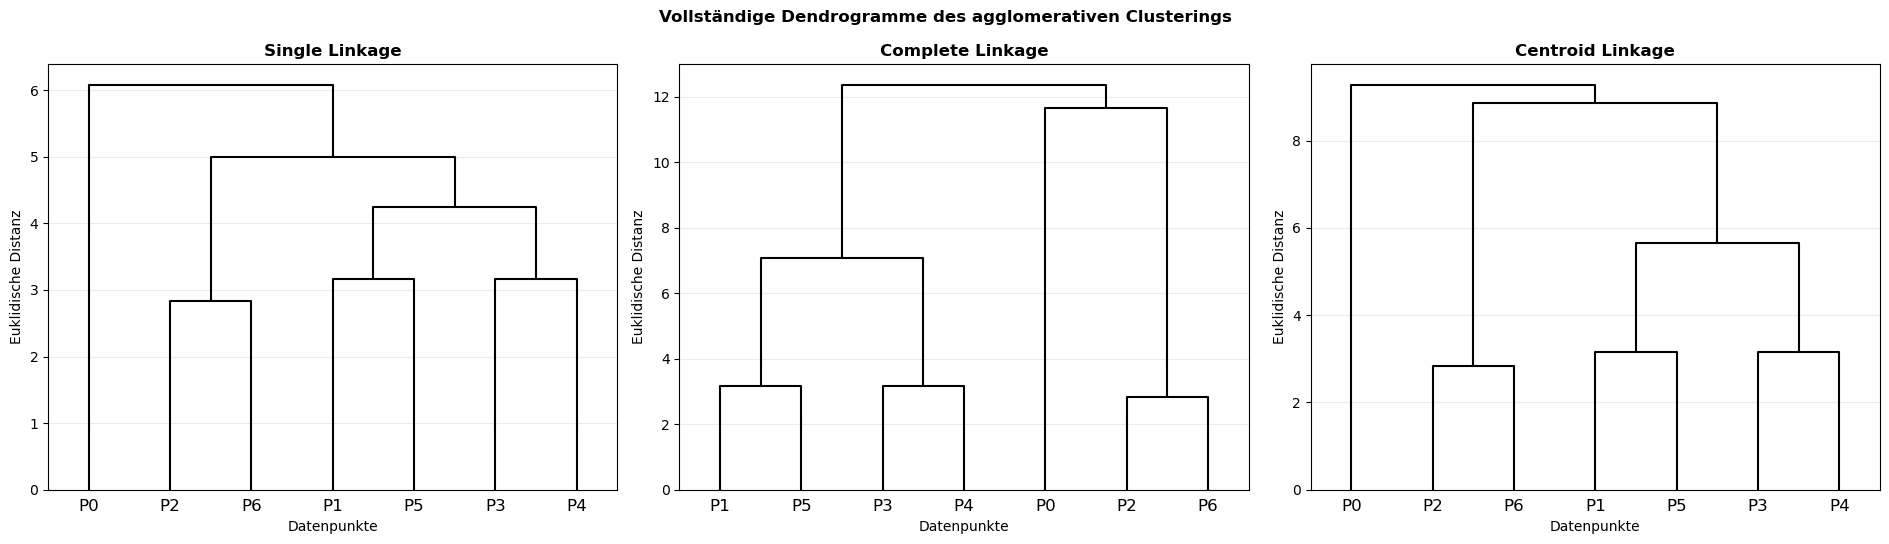

In [4]:
# Agglomeratives Clustering mit drei Linkage-Verfahren
linkage_verfahren = {
    "Single Linkage": "single",
    "Complete Linkage": "complete",
    "Centroid Linkage": "centroid",
}

linkage_matrizen = {}

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, (titel, methode) in zip(axes, linkage_verfahren.items()):
    Z = linkage(daten[["x", "y"]], method=methode, metric="euclidean")
    linkage_matrizen[methode] = Z

    dendrogram(
        Z,
        labels=daten.index.tolist(),
        ax=ax,
        color_threshold=0,
        above_threshold_color="black",
    )
    ax.set_title(titel, fontweight="bold")
    ax.set_xlabel("Datenpunkte")
    ax.set_ylabel("Euklidische Distanz")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Vollständige Dendrogramme des agglomerativen Clusterings", fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
# Vergleich der Verfahren bei einer sinnvollen Interpretation mit drei Gruppen.
# In b) ist keine feste Clusteranzahl vorgegeben; die drei Gruppen entsprechen der
# sichtbaren Struktur aus den Dendrogrammen: zwei Punktgruppen und P0 als Einzelgruppe.
vergleich = []

for titel, methode in linkage_verfahren.items():
    cluster_labels = fcluster(linkage_matrizen[methode], t=3, criterion="maxclust")
    cluster_text = []

    for cluster_id in sorted(set(cluster_labels)):
        punkte = daten.index[cluster_labels == cluster_id].tolist()
        cluster_text.append(f"C{cluster_id}: " + ", ".join(punkte))

    vergleich.append(
        {
            "Verfahren": titel,
            "3-Gruppen-Aufteilung": " | ".join(cluster_text),
            "Nächste Fusion nach Schnitt": round(linkage_matrizen[methode][-2, 2], 4),
        }
    )

vergleich_df = pd.DataFrame(vergleich)
display(vergleich_df.style.hide(axis="index").set_caption("Vergleich der agglomerativen Verfahren"))

Verfahren,3-Gruppen-Aufteilung,Nächste Fusion nach Schnitt
Single Linkage,"C1: P2, P6 | C2: P1, P3, P4, P5 | C3: P0",5.000000
Complete Linkage,"C1: P1, P3, P4, P5 | C2: P2, P6 | C3: P0",11.661900
Centroid Linkage,"C1: P2, P6 | C2: P1, P3, P4, P5 | C3: P0",8.860000


**Auswahl des besten Clusterings:**  
Als bestes Clustering wird **Complete Linkage** gewählt. In Aufgabe b) ist keine feste Anzahl an Clustern vorgegeben, deshalb wird das Dendrogramm dort interpretiert, wo die Struktur am sinnvollsten ist. Bei diesem Datensatz sind drei Gruppen plausibel: `P1, P3, P4, P5`, `P2, P6` und `P0` als einzelne, weit entfernte Gruppe. **Single Linkage** ist schwach, weil es durch den Ketteneffekt getrennte Bereiche schon bei relativ kleiner Distanz verbindet. **Centroid Linkage** ist besser, kann aber durch Schwerpunktbildung ebenfalls früh größere Gruppen zusammenziehen. **Complete Linkage** bewertet die maximale Distanz zwischen Clustern und trennt die Gruppen am stabilsten; die nächste Fusion nach der 3-Gruppen-Struktur erfolgt erst bei einer deutlich höheren Distanz. Deshalb ist Complete Linkage für diesen Datensatz die beste Wahl.

#### c)

In [6]:
# DBSCAN: kurze Parametersuche für genau zwei gültige Cluster.
# Ausreißer mit Label -1 zählen dabei nicht als Cluster.
parameter_test = []

for min_pts_test in [2, 3, 4]:
    for eps_test in [3.0, 3.5, 4.0, 4.25, 4.5, 5.0, 5.5, 6.0]:
        modell = DBSCAN(eps=eps_test, min_samples=min_pts_test)
        labels_test = modell.fit_predict(daten[["x", "y"]])
        cluster_anzahl = len(set(labels_test) - {-1})
        noise_anzahl = list(labels_test).count(-1)

        parameter_test.append(
            {
                "eps": eps_test,
                "MinPts": min_pts_test,
                "gültige Cluster": cluster_anzahl,
                "Geräuschpunkte": noise_anzahl,
                "Labels": ", ".join(map(str, labels_test)),
            }
        )

parameter_test_df = pd.DataFrame(parameter_test)
display(
    parameter_test_df[parameter_test_df["gültige Cluster"] == 2]
    .style
    .hide(axis="index")
    .set_caption("DBSCAN-Parameterkombinationen mit genau zwei gültigen Clustern")
)

eps,MinPts,gültige Cluster,Geräuschpunkte,Labels
4.250000,2,2,1,"-1, 0, 1, 0, 0, 0, 1"
4.500000,2,2,1,"-1, 0, 1, 0, 0, 0, 1"


In [7]:
# Gewählte Parameter aus der Parametersuche
eps = 4.25
min_pts = 2

dbscan = DBSCAN(eps=eps, min_samples=min_pts)
dbscan_labels = dbscan.fit_predict(daten[["x", "y"]])
core_indices = set(dbscan.core_sample_indices_)

dbscan_ergebnis = daten.copy()
dbscan_ergebnis["Cluster"] = ["Ausreißer" if label == -1 else f"Cluster {label}" for label in dbscan_labels]
dbscan_ergebnis["Instanztyp"] = [
    "Geräuschinstanz" if label == -1 else "Kerninstanz" if i in core_indices else "Grenzinstanz"
    for i, label in enumerate(dbscan_labels)
]

anzahl_cluster = len(set(dbscan_labels) - {-1})
kerninstanzen = dbscan_ergebnis[dbscan_ergebnis["Instanztyp"] == "Kerninstanz"].index.tolist()
grenzinstanzen = dbscan_ergebnis[dbscan_ergebnis["Instanztyp"] == "Grenzinstanz"].index.tolist()
geraeuschinstanzen = dbscan_ergebnis[dbscan_ergebnis["Instanztyp"] == "Geräuschinstanz"].index.tolist()

print(f"Gewählte Parameter: eps = {eps}, MinPts = {min_pts}")
print(f"Anzahl gültiger Cluster: {anzahl_cluster}")

display(
    dbscan_ergebnis
    .style
    .set_caption("DBSCAN-Ergebnis und Instanztypen")
)

zusammenfassung = pd.DataFrame(
    {
        "Typ": ["Kerninstanzen", "Grenzinstanzen", "Geräuschinstanzen"],
        "Punkte": [
            ", ".join(kerninstanzen) if kerninstanzen else "keine",
            ", ".join(grenzinstanzen) if grenzinstanzen else "keine",
            ", ".join(geraeuschinstanzen) if geraeuschinstanzen else "keine",
        ],
    }
)

display(zusammenfassung.style.hide(axis="index").set_caption("Kern-, Grenz- und Geräuschinstanzen"))

Gewählte Parameter: eps = 4.25, MinPts = 2
Anzahl gültiger Cluster: 2


,x,y,Cluster,Instanztyp
P0,12,2,Ausreißer,Geräuschinstanz
P1,6,1,Cluster 0,Kerninstanz
P2,4,10,Cluster 1,Kerninstanz
P3,1,6,Cluster 0,Kerninstanz
P4,0,3,Cluster 0,Kerninstanz
P5,3,0,Cluster 0,Kerninstanz
P6,6,12,Cluster 1,Kerninstanz


Typ,Punkte
Kerninstanzen,"P1, P2, P3, P4, P5, P6"
Grenzinstanzen,keine
Geräuschinstanzen,P0


##### Visualisierung des DBSCAN-Ergebnisses

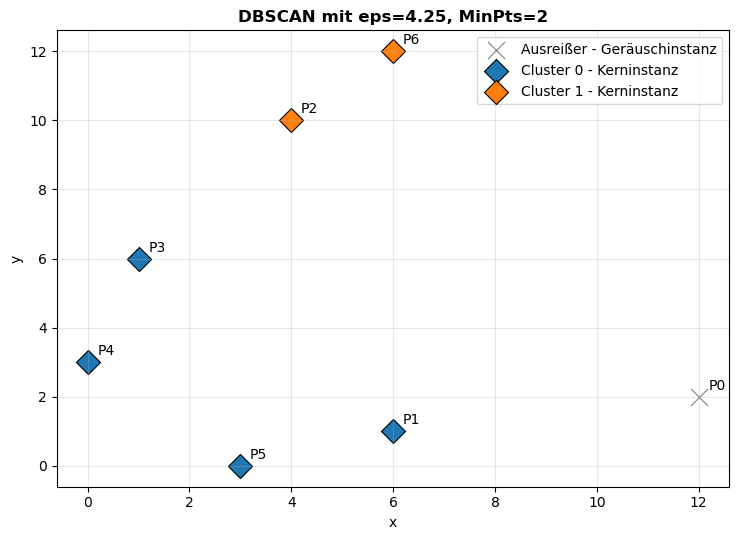

In [8]:
farben = {"Cluster 0": "tab:blue", "Cluster 1": "tab:orange", "Ausreißer": "tab:gray"}
marker = {"Kerninstanz": "D", "Grenzinstanz": "o", "Geräuschinstanz": "x"}

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for punkt, zeile in dbscan_ergebnis.iterrows():
    ax.scatter(
        zeile["x"],
        zeile["y"],
        s=150,
        color=farben[zeile["Cluster"]],
        marker=marker[zeile["Instanztyp"]],
        edgecolor="black" if zeile["Instanztyp"] != "Geräuschinstanz" else None,
        linewidth=0.8,
        label=f'{zeile["Cluster"]} - {zeile["Instanztyp"]}',
    )
    ax.annotate(punkt, (zeile["x"], zeile["y"]), xytext=(7, 5), textcoords="offset points")

# Doppelte Legendeneinträge entfernen
handles, labels_legend = ax.get_legend_handles_labels()
eindeutig = dict(zip(labels_legend, handles))

ax.set_title(f"DBSCAN mit eps={eps}, MinPts={min_pts}", fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
ax.legend(eindeutig.values(), eindeutig.keys(), loc="best")

plt.tight_layout()
plt.show()

**Auswertung DBSCAN:**  
Mit `eps = 4.25` und `MinPts = 2` entstehen genau zwei gültige Cluster. `P0` wird als Geräuschinstanz erkannt, weil der Punkt zu weit von den anderen Punkten entfernt liegt. Die Cluster bestehen aus `P1, P3, P4, P5` sowie `P2, P6`. Alle Punkte in den beiden Clustern sind Kerninstanzen; Grenzinstanzen gibt es bei dieser Parametereinstellung nicht.

#### d)

Sortierte Reihenfolge der Punkte:


,x,y,Cluster,Instanztyp
P1,6,1,Cluster 0,Kerninstanz
P3,1,6,Cluster 0,Kerninstanz
P4,0,3,Cluster 0,Kerninstanz
P5,3,0,Cluster 0,Kerninstanz
P2,4,10,Cluster 1,Kerninstanz
P6,6,12,Cluster 1,Kerninstanz
P0,12,2,Ausreißer,Geräuschinstanz


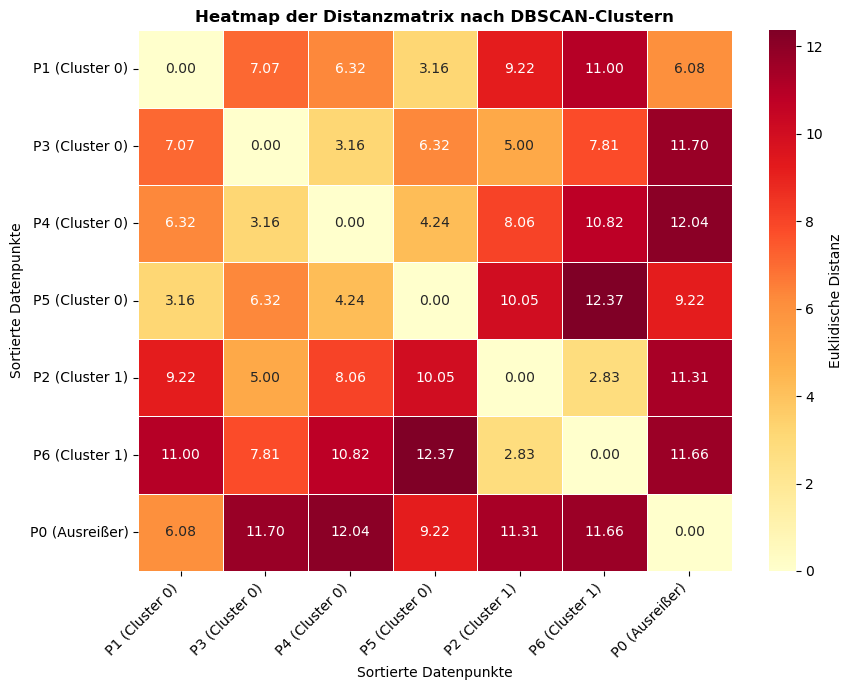

In [9]:
# Distanzmatrix nach dem DBSCAN-Clustering sortieren.
# Cluster 0 und Cluster 1 kommen zuerst, der Ausreißer P0 steht am Ende.
sortier_info = dbscan_ergebnis.copy()
sortier_info["Sortierung"] = dbscan_labels
sortier_info["Sortierung"] = sortier_info["Sortierung"].replace(-1, 99)
sortier_info["Punktnummer"] = [int(punkt[1:]) for punkt in sortier_info.index]
sortier_info = sortier_info.sort_values(["Sortierung", "Punktnummer"])

sortierte_punkte = sortier_info.index.tolist()
daten_sortiert = daten.loc[sortierte_punkte]

distanzmatrix_sortiert = pairwise_distances(daten_sortiert[["x", "y"]], metric="euclidean")
heatmap_labels = [f"{punkt} ({dbscan_ergebnis.loc[punkt, 'Cluster']})" for punkt in sortierte_punkte]

distanzmatrix_sortiert_df = pd.DataFrame(
    distanzmatrix_sortiert,
    index=heatmap_labels,
    columns=heatmap_labels,
)

print("Sortierte Reihenfolge der Punkte:")
display(sortier_info[["x", "y", "Cluster", "Instanztyp"]])

plt.figure(figsize=(9, 7))
sns.heatmap(
    distanzmatrix_sortiert_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Euklidische Distanz"},
)

plt.title("Heatmap der Distanzmatrix nach DBSCAN-Clustern", fontweight="bold")
plt.xlabel("Sortierte Datenpunkte")
plt.ylabel("Sortierte Datenpunkte")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation der Heatmap:**  
Die Heatmap zeigt nach der Sortierung zwei erkennbare Clusterbereiche. `Cluster 1` mit `P2` und `P6` ist sehr kompakt, da die Distanz zwischen diesen beiden Punkten nur `2.83` beträgt. `Cluster 0` mit `P1, P3, P4, P5` ist weniger kompakt, aber durch nahe Nachbarschaften zusammenhängend: `P1` liegt nah bei `P5`, `P5` nah bei `P4` und `P4` nah bei `P3`. Genau diese Dichteverkettung passt zu DBSCAN. `P0` hat zu allen anderen Punkten deutlich größere Distanzen und wird deshalb sinnvoll als Geräuschinstanz erkannt. Insgesamt ist das DBSCAN-Clustering für diesen Datensatz plausibel und gut interpretierbar, aber nicht perfekt kompakt wie ein ideales kugelförmiges Clustering.

## Teil 2

#### a)

In [10]:
random_state_0 = 0
samples,labels,centers = sc.datasets.make_blobs(n_samples=1000, n_features=5, centers=4, cluster_std=3, random_state=random_state_0,return_centers=True)

#### b)

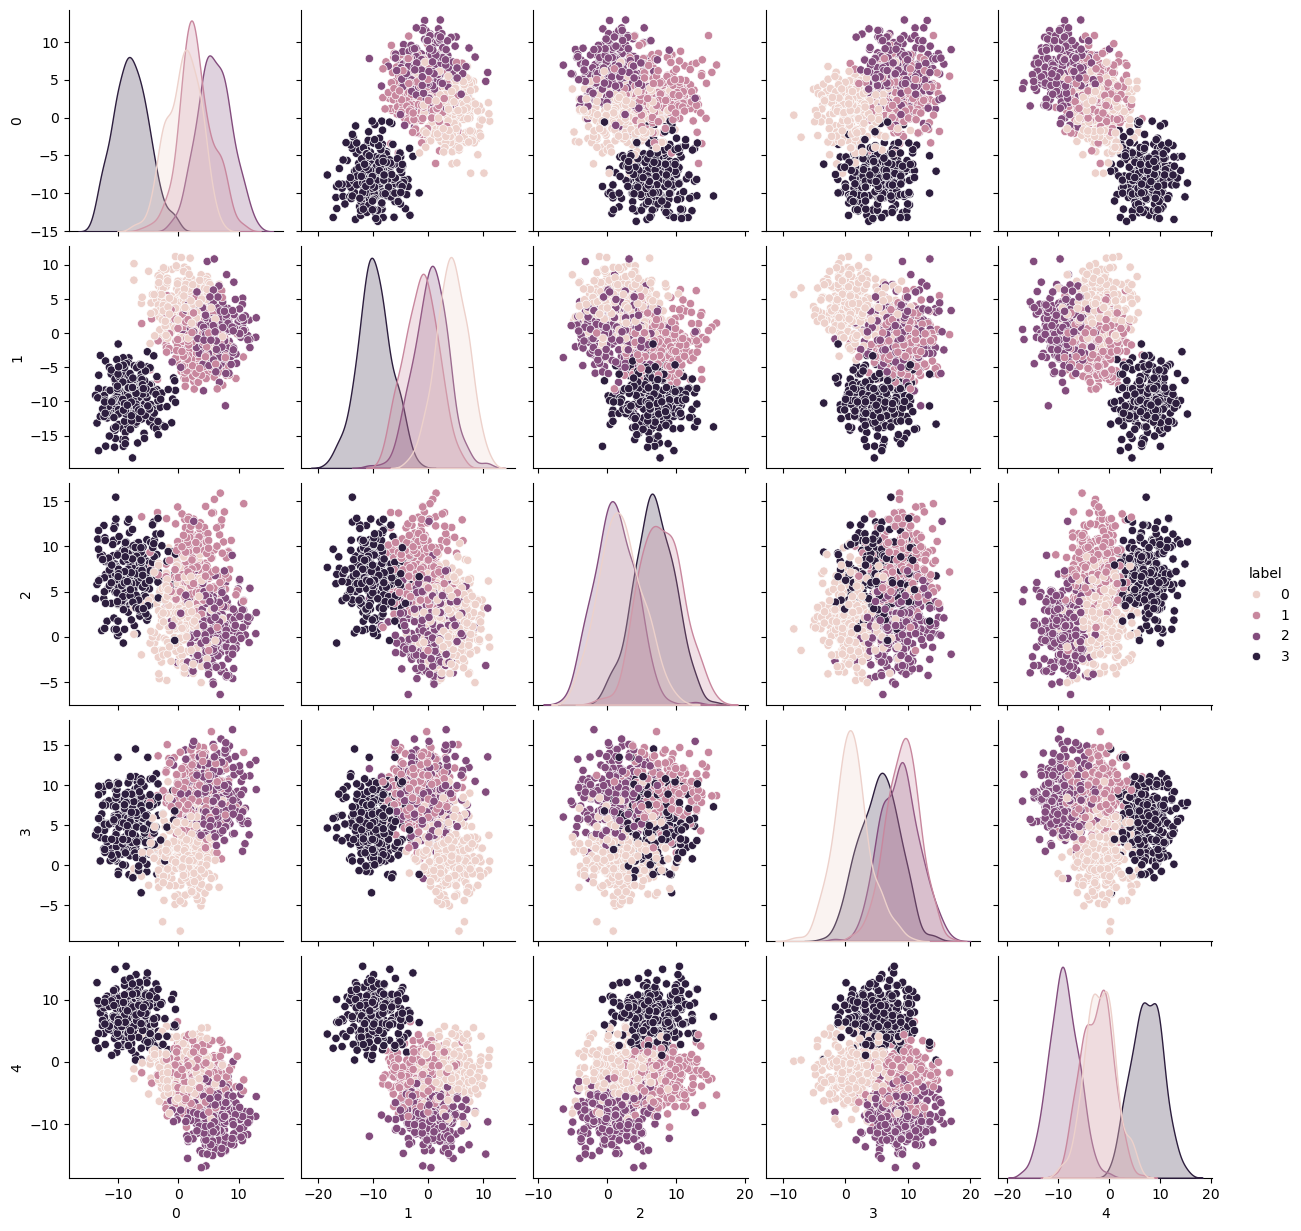

In [11]:
df = pd.DataFrame(samples, columns=[f'{i}' for i in range((centers.shape[1]))])
df["label"]=labels

sns.pairplot(df, hue="label")

#### c)

In [12]:
kmeans = sc.cluster.KMeans(n_clusters=4, random_state=random_state_0).fit(samples)
kmeans_predict = kmeans.predict(samples)

#### d)

In [13]:
kmeans_score = sc.metrics.silhouette_score(X=df, labels=kmeans_predict, random_state=random_state_0)
print(kmeans_score)
# Wir haben uns für silhoutte_score als metrik entschieden da hier mit angegeben wird wie zuverlässig ein wert dem richtigen cluster zugeordnet wird,wo bei 1 eine klare clusterzuordnung ist und -1 einer falschen cluster zuordnung entspricht.
# entsprechend der metrik zeigt sich hier zwar eine zuordnung, die aber eher vage als zuverlässig ist.

0.3756684539692124


#### e)

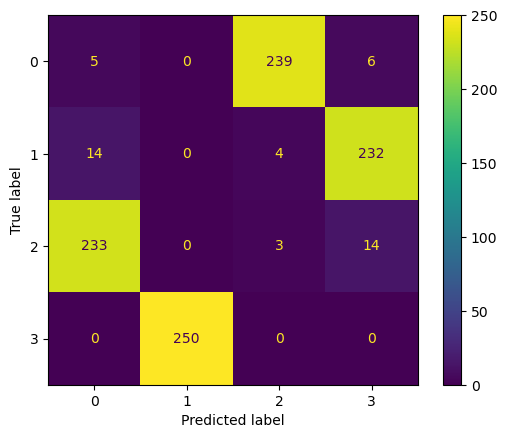

In [14]:
confusion_matrix = sc.metrics.confusion_matrix(y_true=labels, y_pred=kmeans_predict)
disp = sc.metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
disp.plot()
# wie in der Metrik schon zu erahnen war, wird eine Klassifizierung sehr zuverlässig durch geführt der rest ist aber fehlerhaft, eine Konfusionsmatrix ist insofern ein geeignetes werkzeug da hier gut zu erkennen ist in welchem verhältnis und bei welchem Clustern eine korrekte und eine fehlerhafte Klassifikation erfolgt ist.

#### f)

In [15]:
X_train, X_test, y_train, y_test = sc.model_selection.train_test_split(samples, labels, train_size=0.8, random_state=random_state_0)

#### g)

In [16]:
clf = sc.tree.DecisionTreeClassifier(criterion="gini", min_impurity_decrease=0.05)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

#### h)

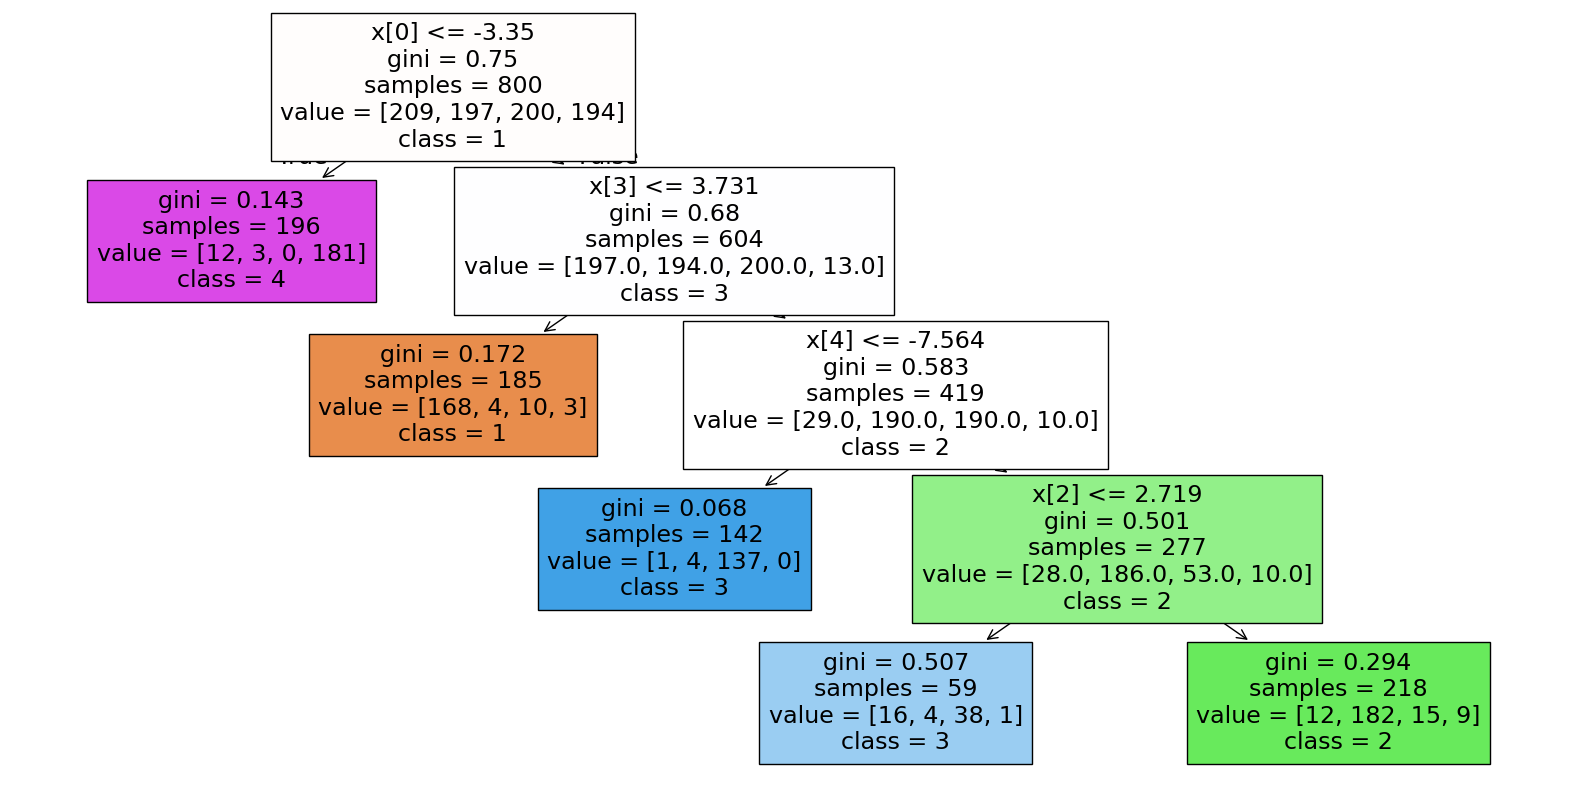

In [17]:
pl.pyplot.figure(figsize=(20, 10))
sc.tree.plot_tree(clf, filled=True,class_names=['1','2','3','4'])
pl.pyplot.show()

#### i)

<Axes: >

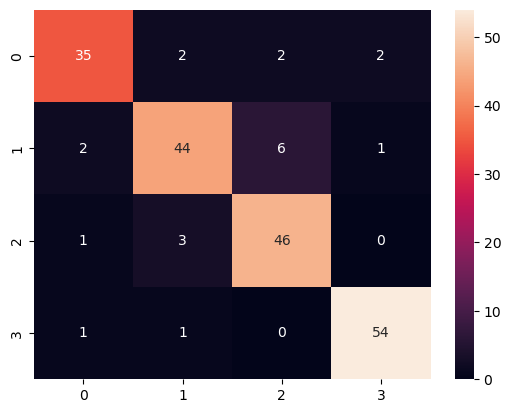

In [18]:
clf_predict = clf.predict(X_test)
confusion_matrix_clf = sc.metrics.confusion_matrix(y_true=y_test, y_pred=clf_predict)
confusion_matrix_df = pd.DataFrame(confusion_matrix_clf)
sns.heatmap(confusion_matrix_df, annot=True)

#### j)

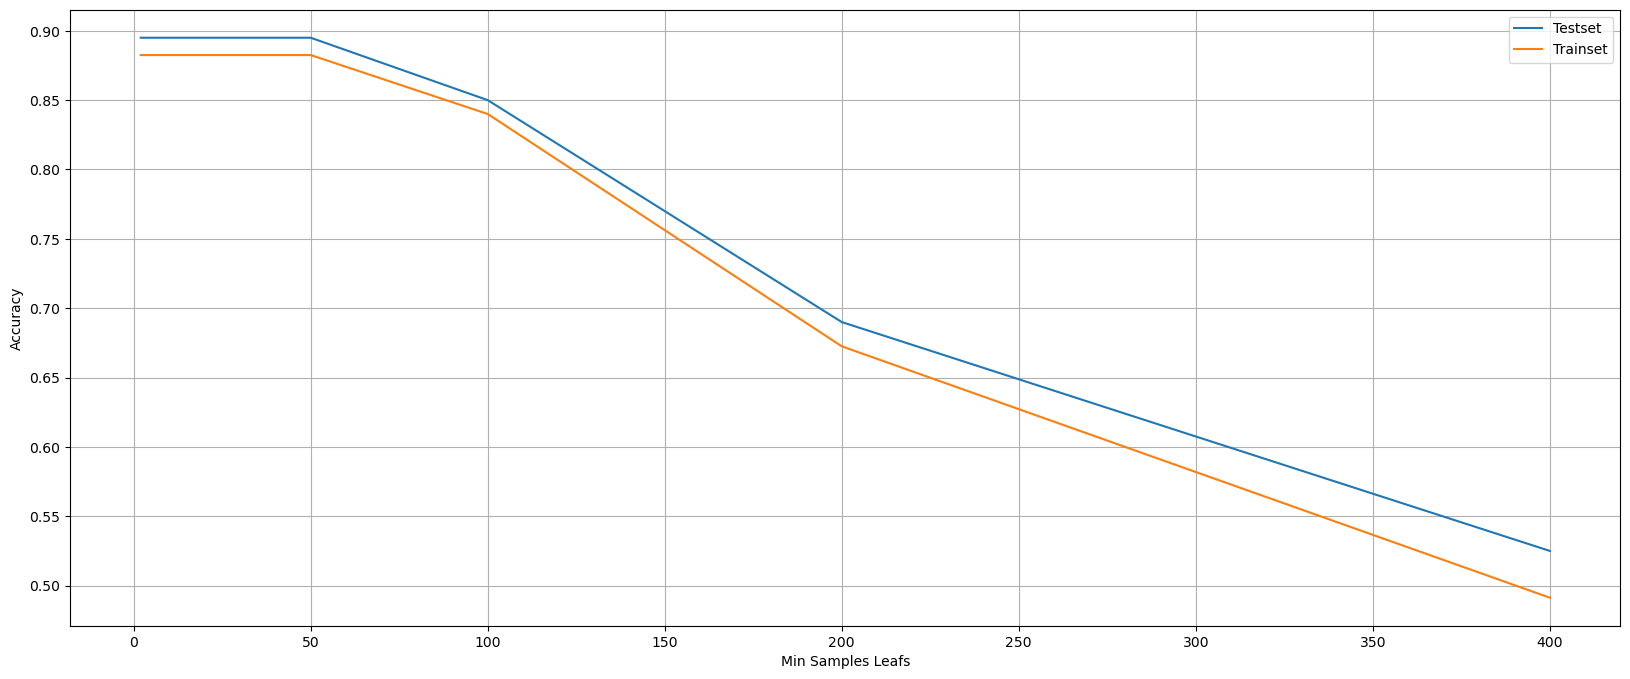

In [19]:
min_samples_leaf = [400, 200, 100, 50, 25, 12, 6, 2]

accuracy_train = []
accuracy_test = []

for i in min_samples_leaf:
    clf_tree = sc.tree.DecisionTreeClassifier(criterion="gini", min_impurity_decrease=0.05, min_samples_leaf=i)
    clf_tree.fit(X_train, y_train)
    clf_tree_predict_test = clf_tree.predict(X_test)
    clf_tree_predict_train = clf_tree.predict(X_train)

    accuracy_train.append(sc.metrics.accuracy_score(y_true=y_train, y_pred=clf_tree_predict_train))
    accuracy_test.append(sc.metrics.accuracy_score(y_true=y_test, y_pred=clf_tree_predict_test))

pl.pyplot.figure(figsize=(20, 8))
pl.pyplot.grid(True)
pl.pyplot.plot(min_samples_leaf, accuracy_test, label="Testset")
pl.pyplot.plot(min_samples_leaf, accuracy_train, label="Trainset")
pl.pyplot.xlabel("Min Samples Leafs")
pl.pyplot.ylabel("Accuracy")
pl.pyplot.legend(loc='best')
pl.pyplot.show()


#### k)

In [20]:
rfc = sc.ensemble.RandomForestClassifier(n_estimators=20,random_state=random_state_0)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

#### i)

Genauigkeit Random-Forest-Klassifikator: 0.94


Text(0.5, 1.0, 'Random-Forest-Klassifikator')

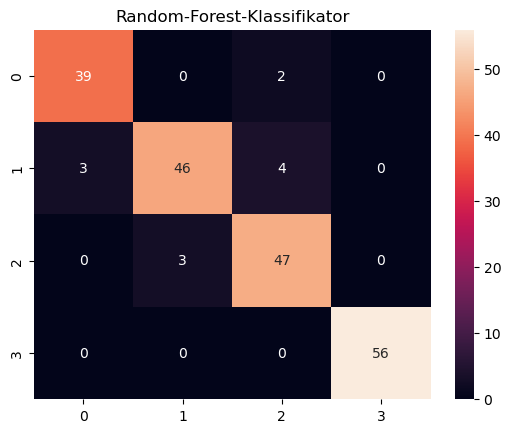

In [21]:
rfc_predict = rfc.predict(X_test)
accuracy_rfc = sc.metrics.accuracy_score(y_true=y_test, y_pred=rfc_predict)
print(f"Genauigkeit Random-Forest-Klassifikator: {accuracy_rfc}")
confusion_matrix_rfc = sc.metrics.confusion_matrix(y_true=y_test, y_pred=rfc_predict)
ax = pl.pyplot.axes()
sns.heatmap(confusion_matrix_rfc, annot=True,ax=ax)
ax.set_title("Random-Forest-Klassifikator")

Genauigkeit Decision-Tree-Klassifikator: 0.895


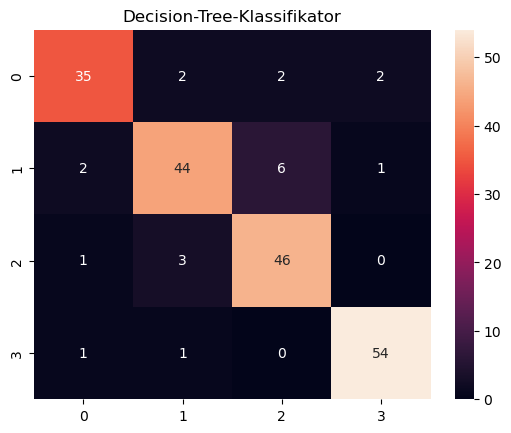

In [22]:
ax = pl.pyplot.axes()
sns.heatmap(confusion_matrix_df, annot=True,ax=ax)
ax.set_title("Decision-Tree-Klassifikator")
accuracy_clf = sc.metrics.accuracy_score(y_true=y_test, y_pred=clf_predict)
print(f"Genauigkeit Decision-Tree-Klassifikator: {accuracy_clf}")

Genauigkeit kmeans Klassifikator: 0.008


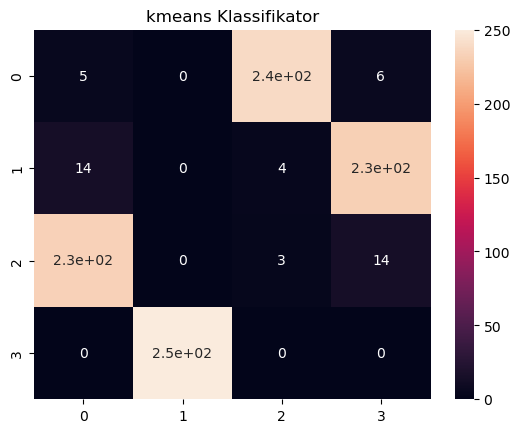

In [23]:
ax = pl.pyplot.axes()
sns.heatmap(confusion_matrix, annot=True,ax=ax)
ax.set_title("kmeans Klassifikator")
accuracy_kmeans = sc.metrics.accuracy_score(y_true=df["label"], y_pred=kmeans_predict)
print(f"Genauigkeit kmeans Klassifikator: {accuracy_kmeans}")

#### m)
##### bericht rfc

In [24]:
report = sc.metrics.classification_report(y_true=y_test,y_pred=rfc_predict)
print(report)
#precision: anteil true positiv zu predicted positiv (tp/(tp+fp) -> zuverlässigkeit der positiven Vorhersagen
#recall: korrekt erkannte positive im verhältnis gesamt Positive (tp/(tp+fn) -> Trefferquote der positiven Fälle
#f1-Score: bezieht Precision und recall zu einem Kenzahl zusammen ((2*pre*rec)/(pre+rec))
#support: Anzahl der Klasse im Datensatz

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        41
           1       0.94      0.87      0.90        53
           2       0.89      0.94      0.91        50
           3       1.00      1.00      1.00        56

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

